# LogisticRegression — Strategy Discovery

**Prerequisites:**
- Run `data/01_build_features.ipynb` to generate `data/latest_features.jsonl`
- Run `lr/02_export.ipynb` to export the model to `models/`

**Goal:** Find the best scaling-in strategy for LogisticRegression.

**Method:** Strategy is discovered on the **validation split** (last 20% of candles from training data),
not on unseen forward-test data. This prevents overfitting the strategy to the test set.

**Output:** `data/optimal_strategy_lr.json`


In [1]:
import sys

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json
import random
import sqlite3
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")
DB_PATH = Path("../../data/collection.db")
MAX_BID = 0.85
WARM_UP = 21

## 1. Load feature config and hyperparameters

Features and hyperparameters from the JSON config. Model will be trained
on the **training split only** (first 80%) to avoid data leakage during
strategy evaluation.


In [2]:
# Load feature config (not the exported model — we train on 80% below)
import json as _json

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

with open(Path("../../data/optimal_features_lr.json")) as _f:
    _config = _json.load(_f)
    feat_cols = sorted(_config["features"])
    _hyperparams = _config.get("hyperparameters", {})

print(f"LR config: {len(feat_cols)} features, params={_hyperparams}")

LR config: 29 features, params={'max_iter': 1000, 'random_state': 42}


## 2. Load data, split, and train on training set

Model is trained on the **first 80%** of candles (training set).
Strategy is discovered on the **last 20%** (validation set).
This prevents data leakage — the model never sees validation data during training.


In [3]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feat_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feat_cols] = df[all_feat_cols].fillna(0.0)

candle_ids = df["candle_id"].unique()
split_idx = int(len(candle_ids) * 0.8)
val_ids = set(candle_ids[split_idx:])
df_val = df[df["candle_id"].isin(val_ids)]

print(f"Total candles: {len(candle_ids)}")
print(f"Validation candles: {df_val['candle_id'].nunique()} (last 20%)")
print(f"Validation rows: {len(df_val):,}")

# Train model on TRAINING SET ONLY (first 80%)
df_train = df[df["candle_id"].isin(set(candle_ids[:split_idx]))]
df_train[feat_cols] = df_train[feat_cols].fillna(0.0)

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feat_cols].values)
y_train = df_train["target"].values

model = LogisticRegression(
    max_iter=_hyperparams.get("max_iter", 1000),
    random_state=_hyperparams.get("random_state", 42),
)
model.fit(X_train, y_train)
print(f"Trained LR on {len(df_train):,} rows ({df_train['candle_id'].nunique()} candles)")

Total candles: 3363
Validation candles: 673 (last 20%)
Validation rows: 31,748
Trained LR on 128,092 rows (2690 candles)


## 3. Build per-snapshot predictions on validation set

In [4]:
all_cd = []

for cid in df_val["candle_id"].unique():
    snap_rows = df_val[df_val["candle_id"] == cid].sort_values("timestamp")
    if len(snap_rows) < 5:
        continue
    truth = int(snap_rows["target"].iloc[0])
    X = scaler.transform(snap_rows[feat_cols].values)
    probs = model.predict_proba(X)[:, 1]

    up_asks = snap_rows["up_best_ask"].values if "up_best_ask" in snap_rows.columns else [None] * len(snap_rows)
    down_asks = snap_rows["down_best_ask"].values if "down_best_ask" in snap_rows.columns else [None] * len(snap_rows)
    elapsed = snap_rows["elapsed_pct"].values

    sd = [
        {
            "tick": i,
            "elapsed_pct": float(elapsed[i]),
            "pred": int(probs[i] >= 0.5),
            "prob": float(probs[i]),
            "up_ask": float(up_asks[i]) if up_asks[i] is not None and np.isfinite(up_asks[i]) else None,
            "down_ask": float(down_asks[i]) if down_asks[i] is not None and np.isfinite(down_asks[i]) else None,
        }
        for i in range(len(snap_rows))
    ]
    all_cd.append({"candle_id": cid, "truth": truth, "snapshots": sd})

print("Built predictions for {len(all_cd)} validation candles")

Built predictions for {len(all_cd)} validation candles


## 4. Scaling-in strategy engine

In [5]:
def run_scaling(name, entry_points, bet_per_entry=10.0, min_confidence=0.0):
    bal = 1000.0
    history = [bal]
    total_bets, total_wins, candles_entered = 0, 0, 0

    for cd in all_cd:
        sd = cd["snapshots"]
        truth = cd["truth"]
        entries = []
        first_direction = None

        for min_e, n_c in entry_points:
            for i in range(max(n_c - 1, 0), len(sd)):
                if sd[i]["elapsed_pct"] < min_e:
                    continue
                if any(i <= prev_tick for prev_tick, _, _ in entries):
                    continue
                if n_c > 1 and not all(sd[i - j]["pred"] == sd[i]["pred"] for j in range(n_c)):
                    continue
                confidence = max(sd[i]["prob"], 1.0 - sd[i]["prob"])
                if confidence < min_confidence:
                    continue
                direction = sd[i]["pred"]
                if first_direction is None:
                    first_direction = direction
                elif direction != first_direction:
                    break
                ask = sd[i]["up_ask"] if direction == 1 else sd[i]["down_ask"]
                if ask is None or not np.isfinite(ask) or ask <= 0 or ask >= MAX_BID:
                    continue
                entries.append((i, direction, ask))
                break

        if not entries:
            continue
        candles_entered += 1
        for _, direction, ask in entries:
            if bal < bet_per_entry:
                break
            total_bets += 1
            if direction == truth:
                bal += (bet_per_entry / ask) * (1.0 - ask)
                total_wins += 1
            else:
                bal -= bet_per_entry
        history.append(bal)

    wr = total_wins / total_bets if total_bets > 0 else 0
    max_dd = (
        max((p - h) / p for p, h in zip([max(history[: i + 1]) for i in range(len(history))], history, strict=False))
        if len(history) > 1
        else 0
    )
    return {
        "name": name,
        "balance": bal,
        "history": history,
        "total_bets": total_bets,
        "candles_entered": candles_entered,
        "wins": total_wins,
        "win_rate": wr,
        "return_pct": (bal - 1000) / 1000 * 100,
        "max_dd": max_dd,
    }

## 5. Test strategies on validation set

In [6]:
strategies = [
    # Single entry
    ("1x e5%", [(0.05, 3)], 0.0),
    ("1x e5% conf>0.6", [(0.05, 3)], 0.6),
    ("1x e5% conf>0.7", [(0.05, 3)], 0.7),
    # Scaling-in: 2 entries
    ("2x e5%+e50%", [(0.05, 3), (0.50, 3)], 0.0),
    ("2x e5%+e50% conf>0.6", [(0.05, 3), (0.50, 3)], 0.6),
    ("2x e5%+e50% conf>0.7", [(0.05, 3), (0.50, 3)], 0.7),
    # Delayed entry
    ("1x e30%", [(0.30, 3)], 0.0),
    ("2x e30%+e60%", [(0.30, 3), (0.60, 3)], 0.0),
    ("2x e30%+e60% conf>0.6", [(0.30, 3), (0.60, 3)], 0.6),
    # Wide scaling
    ("2x e5%+e70%", [(0.05, 3), (0.70, 3)], 0.0),
    ("2x e5%+e70% conf>0.6", [(0.05, 3), (0.70, 3)], 0.6),
]

results = []
print(f"{'Strategy':<30} {'Bets':>5} {'WR':>6} {'Balance':>10} {'Return':>8} {'MaxDD':>7}")
print("-" * 72)

for name, eps, conf in strategies:
    r = run_scaling(name, eps, min_confidence=conf)
    results.append(r)
    print(
        f"{r['name']:<30} {r['total_bets']:>5} "
        f"{r['win_rate'] * 100:>5.1f}% ${r['balance']:>9.2f} {r['return_pct']:>+7.1f}% {r['max_dd'] * 100:>6.1f}%"
    )

Strategy                        Bets     WR    Balance   Return   MaxDD
------------------------------------------------------------------------
1x e5%                           673  63.9% $  1442.37   +44.2%   10.9%
1x e5% conf>0.6                  673  67.3% $  1259.21   +25.9%    8.8%
1x e5% conf>0.7                  666  75.4% $  1324.36   +32.4%    7.0%
2x e5%+e50%                      976  67.9% $  1767.07   +76.7%   11.4%
2x e5%+e50% conf>0.6            1016  70.5% $  1513.32   +51.3%   10.5%
2x e5%+e50% conf>0.7            1067  76.8% $  1511.95   +51.2%    8.6%
1x e30%                          613  68.8% $  1176.26   +17.6%   16.1%
2x e30%+e60%                     934  70.2% $  1274.28   +27.4%   23.2%
2x e30%+e60% conf>0.6            959  72.2% $  1251.47   +25.1%   18.8%
2x e5%+e70%                      911  66.1% $  1501.34   +50.1%   14.4%
2x e5%+e70% conf>0.6             925  69.1% $  1315.94   +31.6%   14.1%


## 6. Equity curves

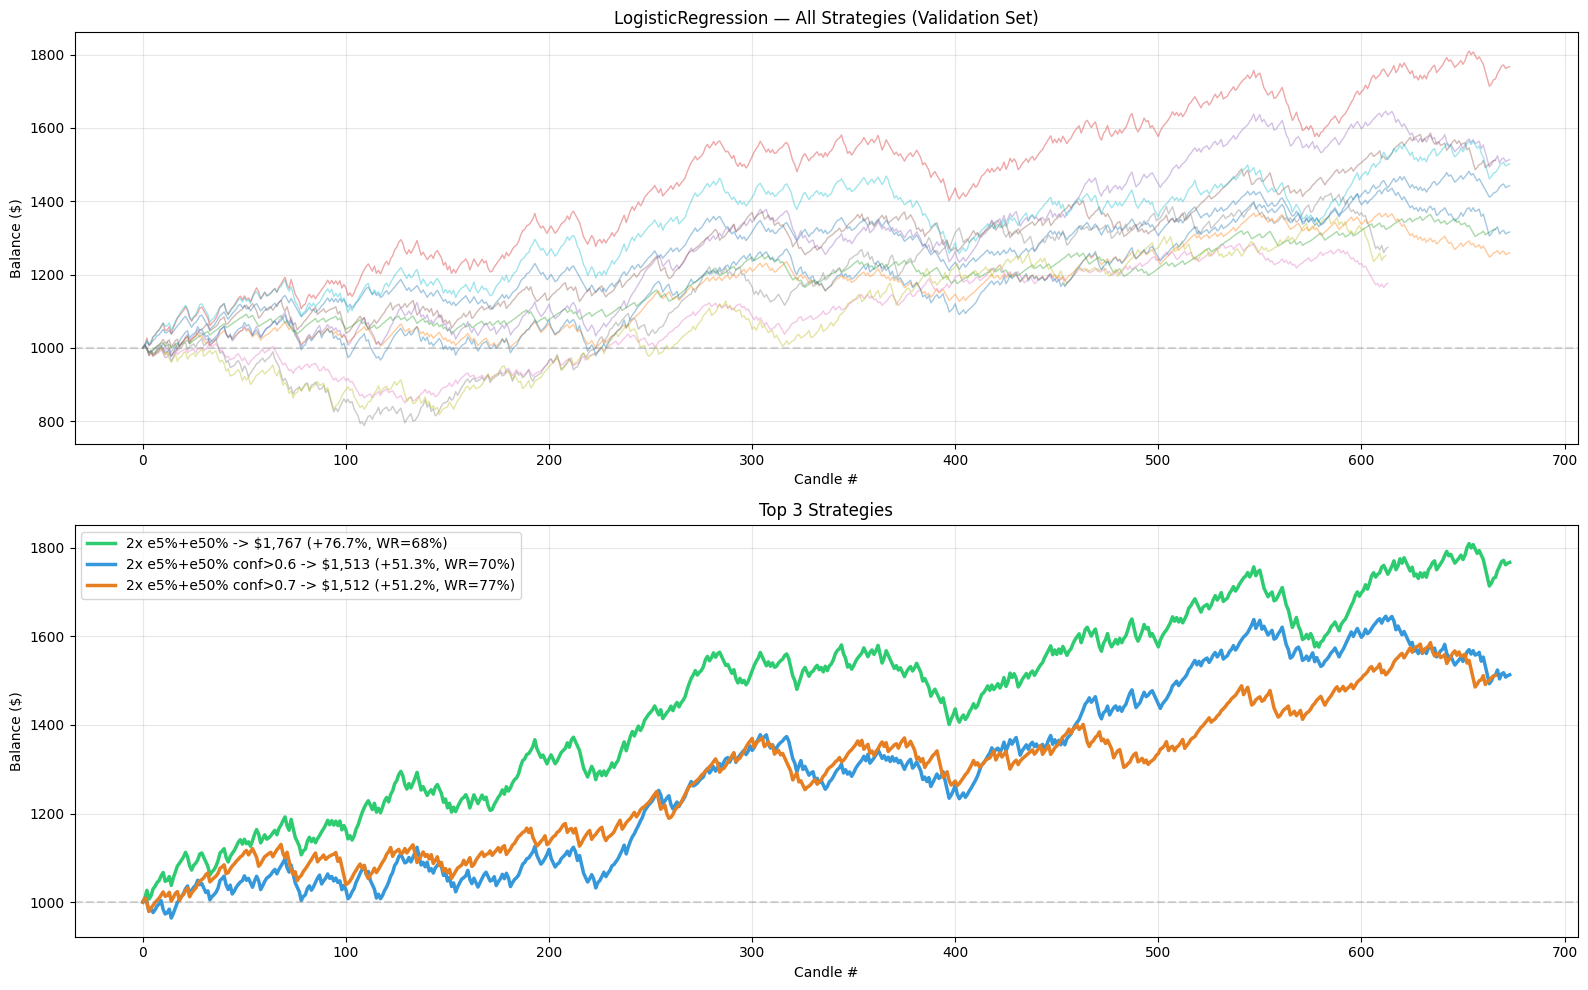

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for r in results:
    axes[0].plot(r["history"], alpha=0.4, linewidth=1)
axes[0].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Candle #")
axes[0].set_ylabel("Balance ($)")
axes[0].set_title("LogisticRegression — All Strategies (Validation Set)")
axes[0].grid(alpha=0.3)

top3 = sorted(results, key=lambda r: -r["balance"])[:3]
colors = ["#2ecc71", "#3498db", "#e67e22"]
for r, c in zip(top3, colors, strict=False):
    axes[1].plot(
        r["history"],
        color=c,
        linewidth=2.5,
        label=f"{r['name']} -> ${r['balance']:,.0f} ({r['return_pct']:+.1f}%, WR={r['win_rate'] * 100:.0f}%)",
    )
axes[1].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Candle #")
axes[1].set_ylabel("Balance ($)")
axes[1].set_title("Top 3 Strategies")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save best strategy

In [8]:
best = max(results, key=lambda r: r["balance"])
best_idx = results.index(best)
best_name, best_eps, best_conf = strategies[best_idx]

config = {
    "model": "lr",
    "strategy": best["name"],
    "entry_points": best_eps,
    "min_confidence": best_conf,
    "win_rate": round(best["win_rate"], 4),
    "return_pct": round(best["return_pct"], 2),
    "max_drawdown": round(best["max_dd"], 4),
    "eval_candles": len(all_cd),
    "eval_method": "validation_split_20pct",
    "total_bets": best["total_bets"],
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../../data/optimal_strategy_lr.json")
with open(out_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Best strategy: {best['name']}")
print(f"  Win rate: {best['win_rate'] * 100:.1f}%")
print(f"  Return: {best['return_pct']:+.1f}%")
print(f"  Max drawdown: {best['max_dd'] * 100:.1f}%")
print(f"  Balance: ${best['balance']:,.2f}")
print("  Eval method: validation split (last 20% of training candles)")
print(f"\nSaved to {out_path}")

Best strategy: 2x e5%+e50%
  Win rate: 67.9%
  Return: +76.7%
  Max drawdown: 11.4%
  Balance: $1,767.07
  Eval method: validation split (last 20% of training candles)

Saved to ../../data/optimal_strategy_lr.json


## 8. (Optional) Forward-test confirmation

Run the chosen strategy on unseen candles from DB to confirm it generalizes.
This is for **reporting only** — the strategy was already selected above on the validation set.

In [9]:
# Load forward-test candles
max_train_ts = df["timestamp"].max()

conn = sqlite3.connect(str(DB_PATH))
candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time > {max_train_ts} ORDER BY start_time",
    conn,
)
snaps_df = (
    pd.read_sql(
        "SELECT * FROM snapshots WHERE candle_id IN ({}) ORDER BY candle_id, timestamp".format(
            ",".join(f"'{cid}'" for cid in candles_df["candle_id"])
        ),
        conn,
    )
    if len(candles_df) > 0
    else pd.DataFrame()
)
prior_candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time <= {max_train_ts} ORDER BY start_time DESC LIMIT {WARM_UP}",
    conn,
)
conn.close()

if len(candles_df) == 0:
    print("No forward-test candles available yet. Skip this section.")
else:
    prior_candles_df = prior_candles_df.sort_values("start_time")
    prior_candles = [
        CandleRecord(
            **{
                k: row[k]
                for k in [
                    "candle_id",
                    "start_time",
                    "end_time",
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "outcome",
                    "final_ret",
                ]
            }
        )
        for _, row in prior_candles_df.iterrows()
    ]

    fwd_rows = []
    for _, cr in tqdm(candles_df.iterrows(), total=len(candles_df), desc="Forward-test features"):
        cid = cr["candle_id"]
        candle = CandleRecord(
            **{
                k: cr[k]
                for k in [
                    "candle_id",
                    "start_time",
                    "end_time",
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "outcome",
                    "final_ret",
                ]
            }
        )
        snap_rows = snaps_df[snaps_df["candle_id"] == cid]
        if len(snap_rows) < 5:
            prior_candles.append(candle)
            continue
        snapshots = []
        for _, s in snap_rows.iterrows():
            ob = json.loads(s["orderbook_json"])
            snapshots.append(
                IndicatorSnapshot(
                    candle_id=cid,
                    timestamp=s["timestamp"],
                    elapsed_pct=s["elapsed_pct"],
                    btc_price=s["btc_price"],
                    btc_bid=s["btc_bid"],
                    btc_ask=s["btc_ask"],
                    up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                    up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                    down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                    down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                    market_volume=s["market_volume"],
                )
            )
        for si in range(len(snapshots)):
            indicators = compute_all(prior_candles, candle.open, snapshots[: si + 1])
            snap = snapshots[si]
            fwd_rows.append(
                {
                    "candle_id": cid,
                    "timestamp": snap.timestamp,
                    "elapsed_pct": snap.elapsed_pct,
                    "btc_price": snap.btc_price,
                    "up_best_ask": snap.up_asks[0][0] if snap.up_asks else None,
                    "down_best_ask": snap.down_asks[0][0] if snap.down_asks else None,
                    **indicators,
                    "outcome": candle.outcome,
                }
            )
        prior_candles.append(candle)

    df_fwd = pd.DataFrame(fwd_rows)
    df_fwd["target"] = (df_fwd["outcome"] == "UP").astype(int)
    df_fwd[all_feat_cols] = df_fwd[all_feat_cols].fillna(0.0)

    fwd_cd = []
    for cid in df_fwd["candle_id"].unique():
        snap_rows = df_fwd[df_fwd["candle_id"] == cid].sort_values("timestamp")
        if len(snap_rows) < 5:
            continue
        truth = int(snap_rows["target"].iloc[0])
        X = scaler.transform(snap_rows[feat_cols].values)
        probs = model.predict_proba(X)[:, 1]
        up_asks = snap_rows["up_best_ask"].values
        down_asks = snap_rows["down_best_ask"].values
        elapsed = snap_rows["elapsed_pct"].values
        sd = [
            {
                "tick": i,
                "elapsed_pct": float(elapsed[i]),
                "pred": int(probs[i] >= 0.5),
                "prob": float(probs[i]),
                "up_ask": float(up_asks[i]) if up_asks[i] is not None and np.isfinite(up_asks[i]) else None,
                "down_ask": float(down_asks[i]) if down_asks[i] is not None and np.isfinite(down_asks[i]) else None,
            }
            for i in range(len(snap_rows))
        ]
        fwd_cd.append({"candle_id": cid, "truth": truth, "snapshots": sd})

    # Run the chosen strategy on forward-test
    old_cd = all_cd
    all_cd = fwd_cd
    fwd_result = run_scaling(best["name"], best_eps, min_confidence=best_conf)
    all_cd = old_cd

    print(f"\nForward-test confirmation ({len(fwd_cd)} unseen candles):")
    print(f"  Strategy: {best['name']}")
    print(f"  Bets: {fwd_result['total_bets']}")
    print(f"  Win rate: {fwd_result['win_rate'] * 100:.1f}%")
    print(f"  Return: {fwd_result['return_pct']:+.1f}%")
    print(f"  Max DD: {fwd_result['max_dd'] * 100:.1f}%")
    print(f"  Balance: ${fwd_result['balance']:,.2f}")

Forward-test features: 100%|██████████| 1/1 [00:00<00:00, 120.37it/s]


Forward-test confirmation (1 unseen candles):
  Strategy: 2x e5%+e50%
  Bets: 1
  Win rate: 0.0%
  Return: -1.0%
  Max DD: 1.0%
  Balance: $990.00


## Conclusion

Best LogisticRegression strategy discovered on **validation split** (last 20% of training candles).
Model was trained on the **first 80%** — no data leakage.

Saved to `data/optimal_strategy_lr.json`.

**Note:** The exported model in `models/` (from `02_export`) is trained on ALL data
for maximum live performance. The strategy was evaluated on held-out data to prevent overfitting.
